# Exploratory Data Analysis (EDA)
## Fraud Detection Project - Task 1a

This notebook performs comprehensive EDA including:
- Univariate analysis
- Bivariate analysis
- Class distribution visualization
- Temporal patterns
- Correlation analysis

In [18]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline

## 1. Load Cleaned Data

In [19]:
# Load cleaned data
fraud_df = pd.read_csv('../data/processed/cleaned_fraud_data.csv')
creditcard_df = pd.read_csv('../data/processed/cleaned_creditcard.csv')

# Convert datetime columns
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

print(f"Fraud data shape: {fraud_df.shape}")
print(f"Credit card data shape: {creditcard_df.shape}")

Fraud data shape: (151112, 11)
Credit card data shape: (283726, 31)


## 2. Class Distribution Analysis

In [20]:
# Fraud data class distribution
fraud_class_dist = fraud_df['class'].value_counts()
fraud_class_pct = fraud_df['class'].value_counts(normalize=True) * 100

print("Fraud Data - Class Distribution:")
print(f"Non-Fraud (0): {fraud_class_dist[0]} ({fraud_class_pct[0]:.2f}%)")
print(f"Fraud (1): {fraud_class_dist[1]} ({fraud_class_pct[1]:.2f}%)")
print(f"\nImbalance Ratio: 1:{fraud_class_dist[0]/fraud_class_dist[1]:.2f}")

Fraud Data - Class Distribution:
Non-Fraud (0): 136961 (90.64%)
Fraud (1): 14151 (9.36%)

Imbalance Ratio: 1:9.68


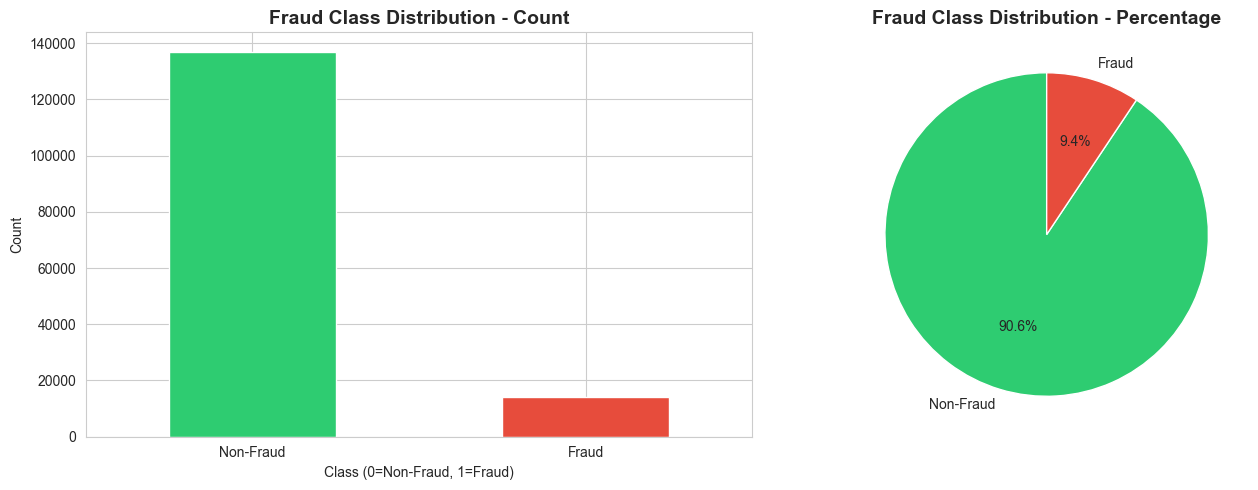

In [21]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
fraud_class_dist.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Fraud Class Distribution - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (0=Non-Fraud, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'], rotation=0)

# Pie chart
axes[1].pie(fraud_class_dist, labels=['Non-Fraud', 'Fraud'], 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Fraud Class Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# Credit card class distribution
cc_class_dist = creditcard_df['Class'].value_counts()
cc_class_pct = creditcard_df['Class'].value_counts(normalize=True) * 100

print("Credit Card Data - Class Distribution:")
print(f"Non-Fraud (0): {cc_class_dist[0]} ({cc_class_pct[0]:.2f}%)")
print(f"Fraud (1): {cc_class_dist[1]} ({cc_class_pct[1]:.2f}%)")
print(f"\nImbalance Ratio: 1:{cc_class_dist[0]/cc_class_dist[1]:.2f}")

Credit Card Data - Class Distribution:
Non-Fraud (0): 283253 (99.83%)
Fraud (1): 473 (0.17%)

Imbalance Ratio: 1:598.84


## 3. Univariate Analysis - Numerical Features

In [23]:
# Summary statistics
fraud_df[['age', 'purchase_value']].describe()

,age,purchase_value
count,151112.000000,151112.000000
mean,33.140704,36.935372
std,8.617733,18.322762
min,18.000000,9.000000
25%,27.000000,22.000000
50%,33.000000,35.000000
75%,39.000000,49.000000
max,76.000000,154.000000


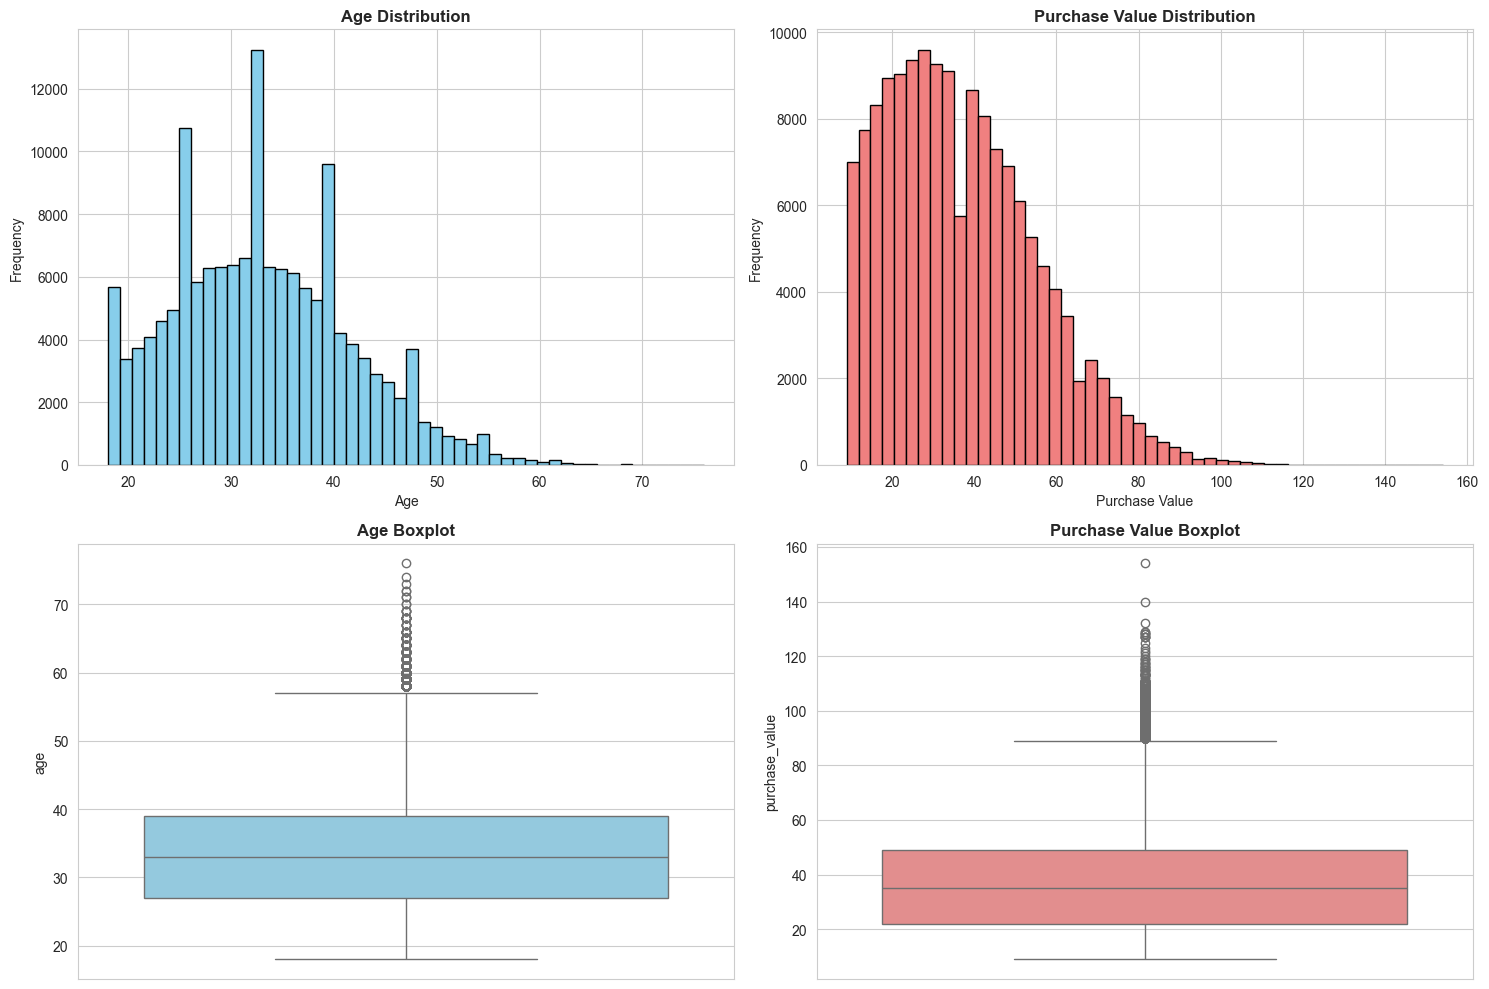

In [24]:
# Distribution plots for numerical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age distribution
axes[0, 0].hist(fraud_df['age'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Purchase value distribution
axes[0, 1].hist(fraud_df['purchase_value'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Purchase Value Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Purchase Value')
axes[0, 1].set_ylabel('Frequency')

# Age boxplot
sns.boxplot(data=fraud_df, y='age', ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Age Boxplot', fontsize=12, fontweight='bold')

# Purchase value boxplot
sns.boxplot(data=fraud_df, y='purchase_value', ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('Purchase Value Boxplot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Univariate Analysis - Categorical Features

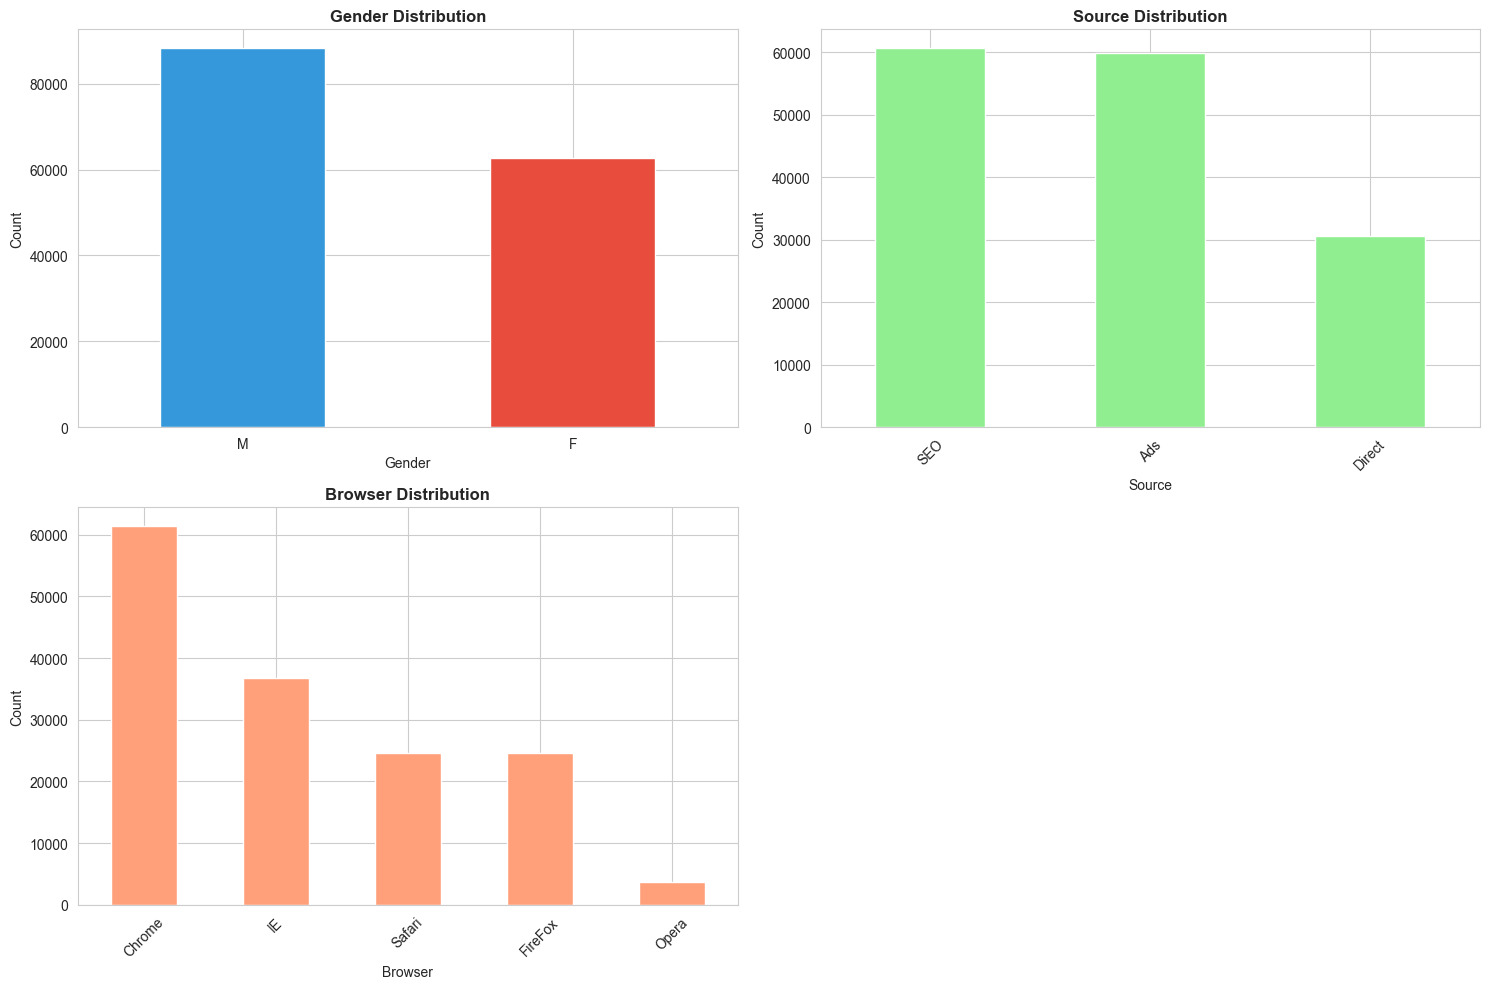

In [25]:
# Categorical features distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gender distribution
fraud_df['sex'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c'])
axes[0, 0].set_title('Gender Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Gender')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)

# Source distribution
fraud_df['source'].value_counts().plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Source Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Source')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)

# Browser distribution
fraud_df['browser'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightsalmon')
axes[1, 0].set_title('Browser Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Browser')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

# Remove empty subplot
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

## 5. Bivariate Analysis - Features vs Fraud Class

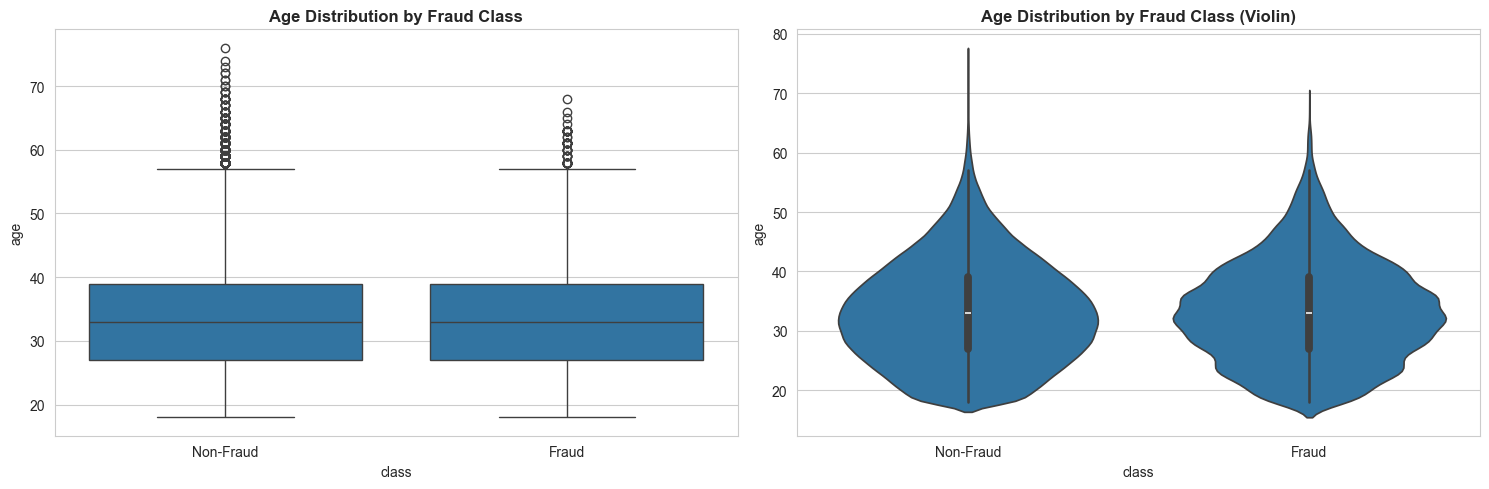

In [26]:
# Age distribution by fraud class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(data=fraud_df, x='class', y='age', ax=axes[0])
axes[0].set_title('Age Distribution by Fraud Class', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])

# Violin plot
sns.violinplot(data=fraud_df, x='class', y='age', ax=axes[1])
axes[1].set_title('Age Distribution by Fraud Class (Violin)', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

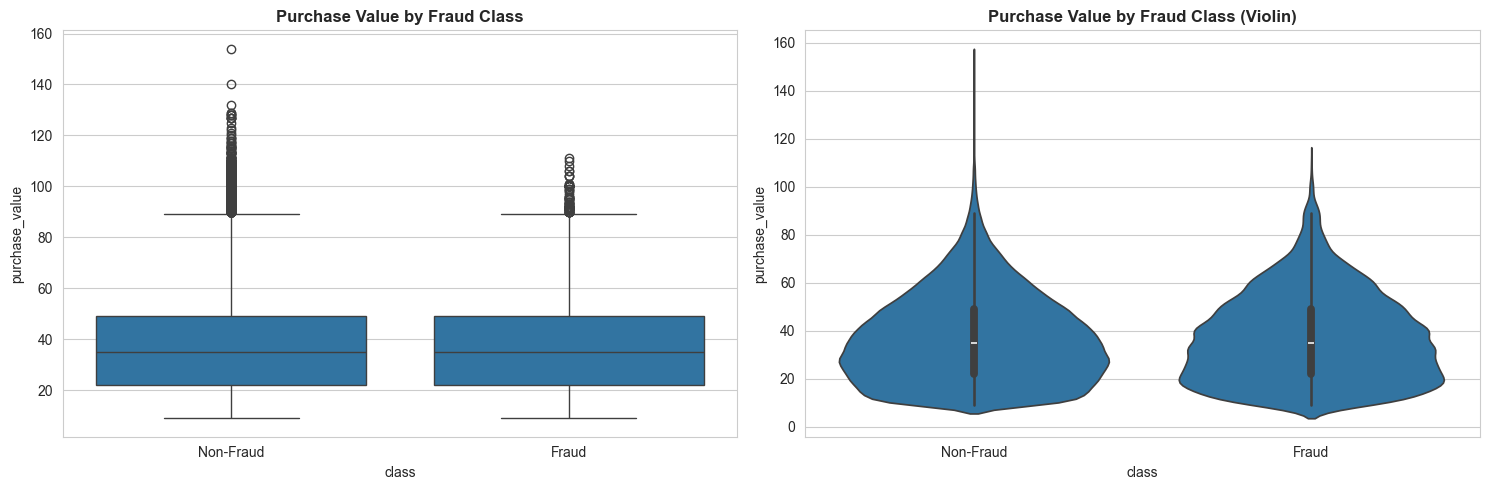

In [27]:
# Purchase value distribution by fraud class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=fraud_df, x='class', y='purchase_value', ax=axes[0])
axes[0].set_title('Purchase Value by Fraud Class', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])

sns.violinplot(data=fraud_df, x='class', y='purchase_value', ax=axes[1])
axes[1].set_title('Purchase Value by Fraud Class (Violin)', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

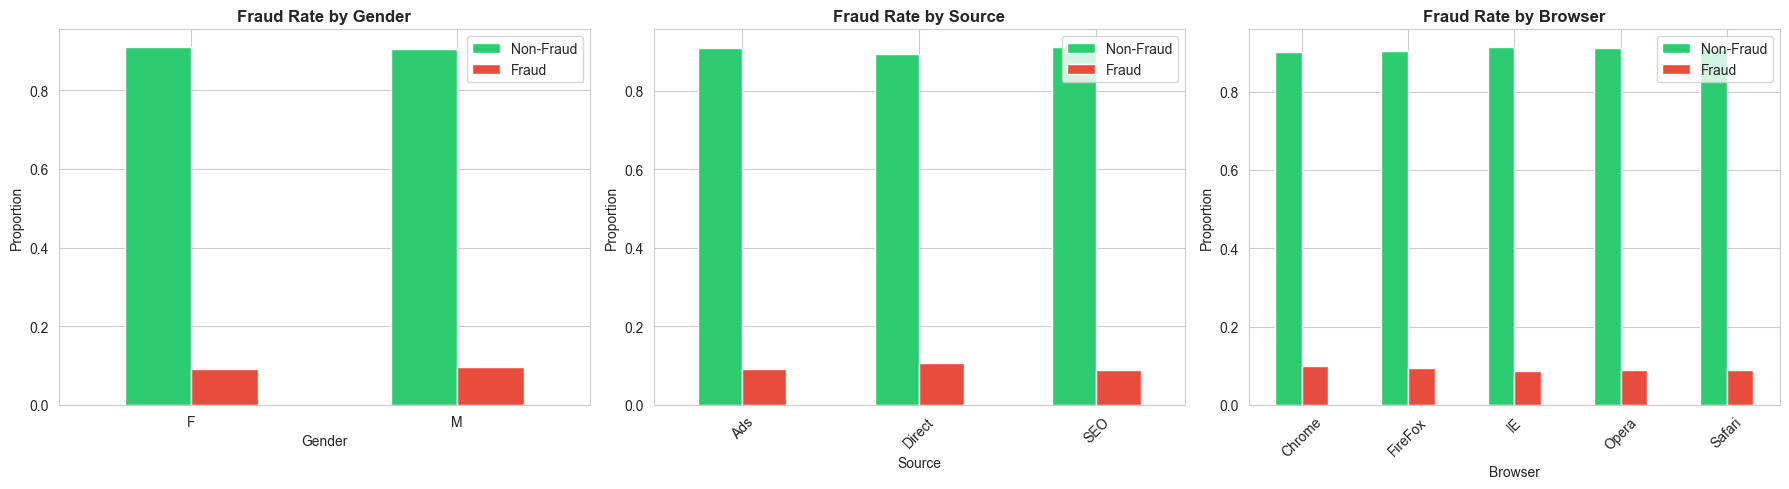

In [28]:
# Categorical features vs fraud class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender vs fraud
pd.crosstab(fraud_df['sex'], fraud_df['class'], normalize='index').plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Fraud Rate by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Proportion')
axes[0].legend(['Non-Fraud', 'Fraud'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Source vs fraud
pd.crosstab(fraud_df['source'], fraud_df['class'], normalize='index').plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c']
)
axes[1].set_title('Fraud Rate by Source', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Proportion')
axes[1].legend(['Non-Fraud', 'Fraud'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

# Browser vs fraud
pd.crosstab(fraud_df['browser'], fraud_df['class'], normalize='index').plot(
    kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c']
)
axes[2].set_title('Fraud Rate by Browser', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Browser')
axes[2].set_ylabel('Proportion')
axes[2].legend(['Non-Fraud', 'Fraud'])
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 6. Temporal Analysis

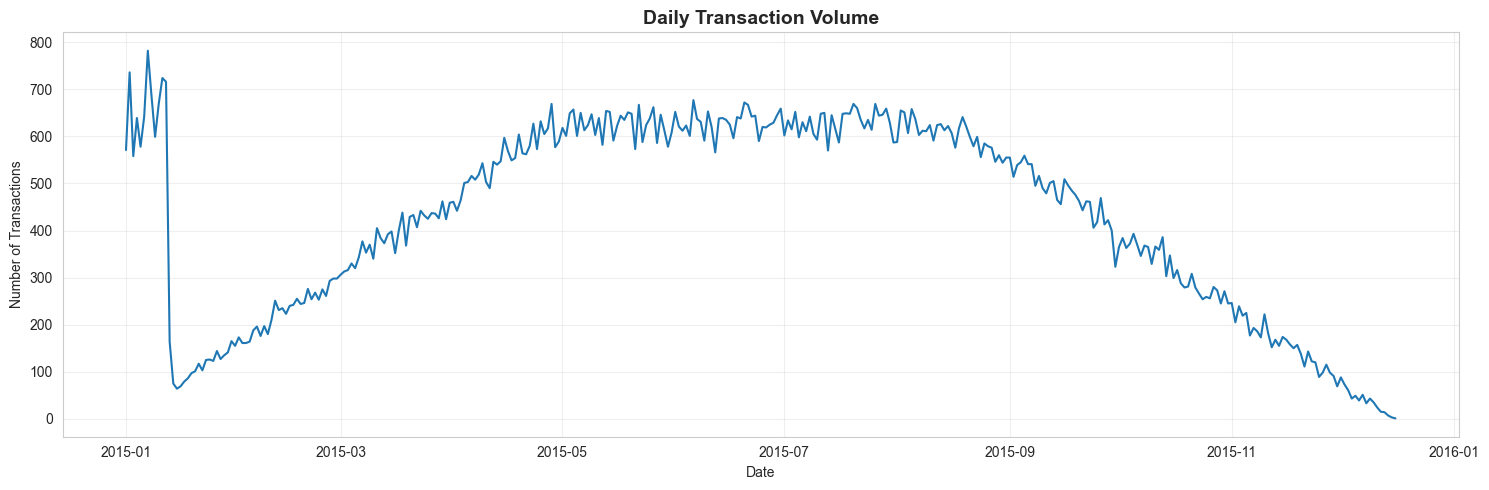

In [29]:
# Extract time features
fraud_df['purchase_hour'] = fraud_df['purchase_time'].dt.hour
fraud_df['purchase_day'] = fraud_df['purchase_time'].dt.dayofweek
fraud_df['purchase_month'] = fraud_df['purchase_time'].dt.month

# Transactions over time
fraud_df['purchase_date'] = fraud_df['purchase_time'].dt.date
daily_transactions = fraud_df.groupby('purchase_date').size()

plt.figure(figsize=(15, 5))
daily_transactions.plot()
plt.title('Daily Transaction Volume', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

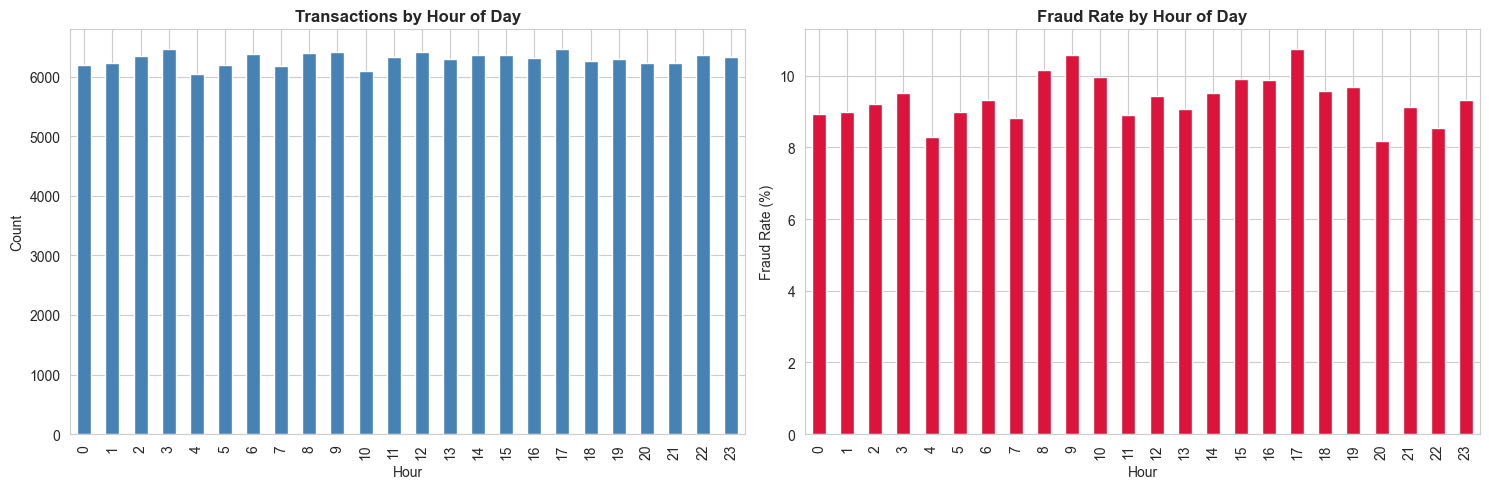

In [30]:
# Fraud patterns by hour of day
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Transaction volume by hour
fraud_df.groupby('purchase_hour').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Transactions by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

# Fraud rate by hour
hourly_fraud = fraud_df.groupby('purchase_hour')['class'].mean() * 100
hourly_fraud.plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Fraud Rate by Hour of Day', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

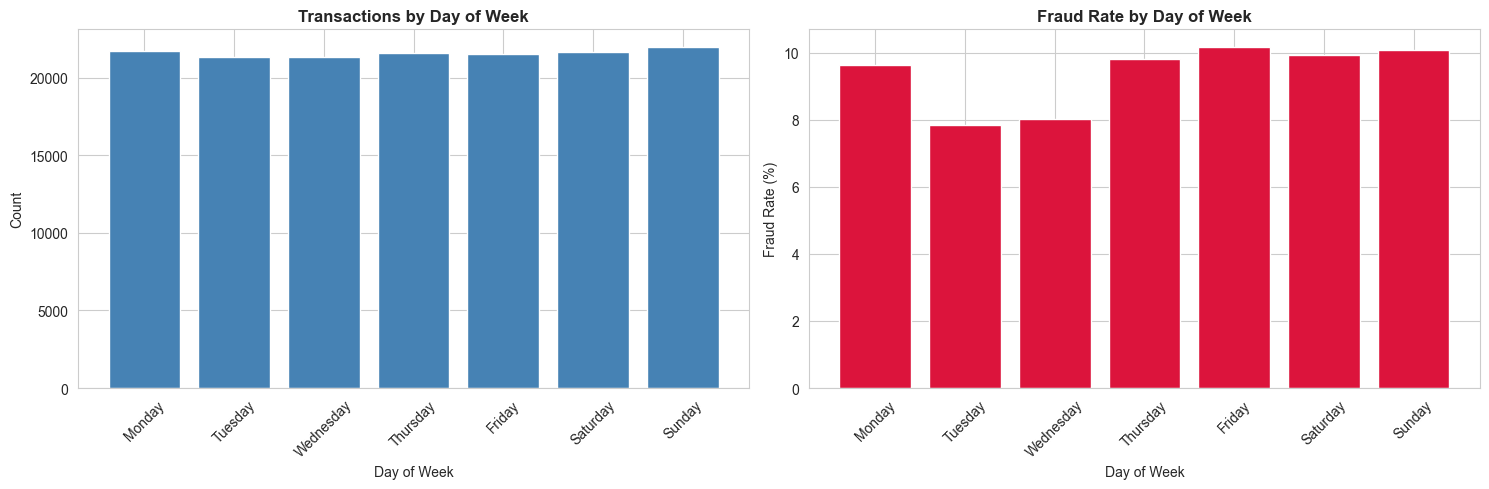

In [31]:
# Fraud patterns by day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Transaction volume by day
dow_counts = fraud_df.groupby('purchase_day').size()
axes[0].bar(range(7), dow_counts, color='steelblue')
axes[0].set_title('Transactions by Day of Week', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names, rotation=45)

# Fraud rate by day
dow_fraud = fraud_df.groupby('purchase_day')['class'].mean() * 100
axes[1].bar(range(7), dow_fraud, color='crimson')
axes[1].set_title('Fraud Rate by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names, rotation=45)

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

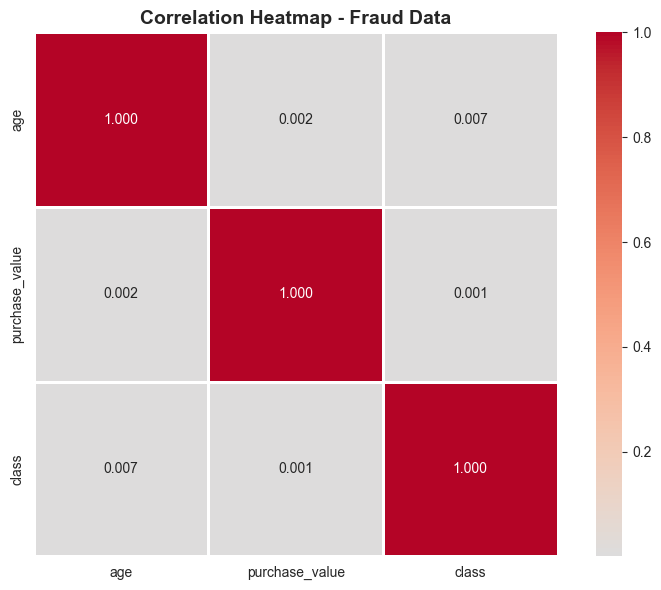

In [32]:
# Select numerical columns for correlation
numerical_cols = ['age', 'purchase_value', 'class']
correlation_matrix = fraud_df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=1)
plt.title('Correlation Heatmap - Fraud Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

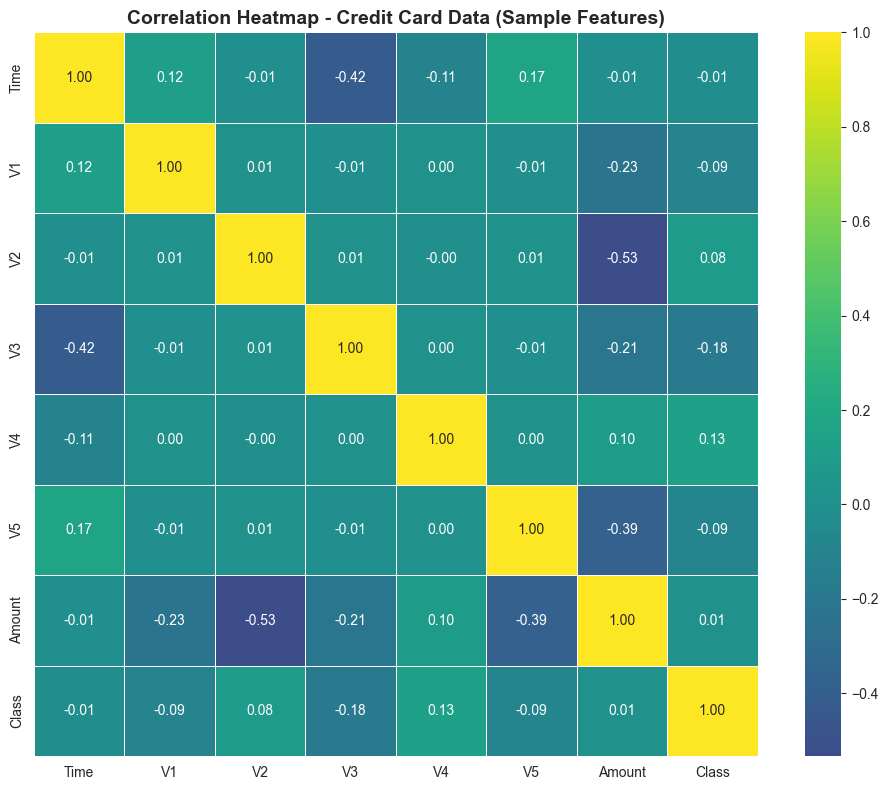

In [33]:
# Credit card correlation (sample of features)
cc_cols = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Class']
cc_corr = creditcard_df[cc_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(cc_corr, annot=True, cmap='viridis', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Credit Card Data (Sample Features)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Key Findings Summary

In [34]:
# Summary statistics by class
print("="*60)
print("KEY FINDINGS SUMMARY")
print("="*60)

print("\n1. CLASS IMBALANCE:")
print(f"   - Fraud transactions: {fraud_class_pct[1]:.2f}%")
print(f"   - Non-fraud transactions: {fraud_class_pct[0]:.2f}%")
print(f"   - Imbalance ratio: 1:{fraud_class_dist[0]/fraud_class_dist[1]:.2f}")

print("\n2. NUMERICAL FEATURES:")
print(f"   - Average age (Fraud): {fraud_df[fraud_df['class']==1]['age'].mean():.2f}")
print(f"   - Average age (Non-Fraud): {fraud_df[fraud_df['class']==0]['age'].mean():.2f}")
print(f"   - Average purchase (Fraud): ${fraud_df[fraud_df['class']==1]['purchase_value'].mean():.2f}")
print(f"   - Average purchase (Non-Fraud): ${fraud_df[fraud_df['class']==0]['purchase_value'].mean():.2f}")

print("\n3. CATEGORICAL PATTERNS:")
fraud_by_gender = fraud_df.groupby('sex')['class'].mean() * 100
fraud_by_source = fraud_df.groupby('source')['class'].mean() * 100
print(f"   - Fraud rate by gender: {fraud_by_gender.to_dict()}")
print(f"   - Highest fraud source: {fraud_by_source.idxmax()} ({fraud_by_source.max():.2f}%)")

print("\n4. TEMPORAL PATTERNS:")
print(f"   - Peak transaction hour: {fraud_df.groupby('purchase_hour').size().idxmax()}")
print(f"   - Highest fraud rate hour: {hourly_fraud.idxmax()} ({hourly_fraud.max():.2f}%)")

print("\n" + "="*60)

KEY FINDINGS SUMMARY

1. CLASS IMBALANCE:
   - Fraud transactions: 9.36%
   - Non-fraud transactions: 90.64%
   - Imbalance ratio: 1:9.68

2. NUMERICAL FEATURES:
   - Average age (Fraud): 33.32
   - Average age (Non-Fraud): 33.12
   - Average purchase (Fraud): $36.99
   - Average purchase (Non-Fraud): $36.93

3. CATEGORICAL PATTERNS:
   - Fraud rate by gender: {'F': 9.100749773157803, 'M': 9.552286138198951}
   - Highest fraud source: Direct (10.54%)

4. TEMPORAL PATTERNS:
   - Peak transaction hour: 17
   - Highest fraud rate hour: 17 (10.75%)



## Conclusions

### Main Insights from EDA:

1. **Severe Class Imbalance**: The dataset shows significant class imbalance with fraud transactions representing a small minority

2. **Feature Patterns**: 
   - Age and purchase value show different distributions for fraud vs non-fraud transactions
   - Certain sources and browsers are associated with higher fraud rates

3. **Temporal Trends**:
   - Fraud patterns vary by hour of day and day of week
   - Specific time periods show elevated fraud risk

4. **Next Steps**:
   - Feature engineering to capture time-based patterns
   - Geographic feature creation using IP mapping
   - Address class imbalance using SMOTE or similar techniques